# Bank Credit Card Churn Prediction
## Exploratory Data Analysis (EDA)

The goal of this notebook is to deeply explore the dataset, understand distributions,
identify patterns, and find the key factors that separate churned customers from existing ones.
These findings will directly guide my modeling decisions.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Cleaned Dataset

In [2]:
df = pd.read_csv('BankChurners.csv')
df=df.iloc[:,:-2]
df['Churn']=(df['Attrition_Flag']=='Attrited Customer').astype(int)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 10127 rows, 22 columns


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


### PART 1: Churn Distribution Analysis

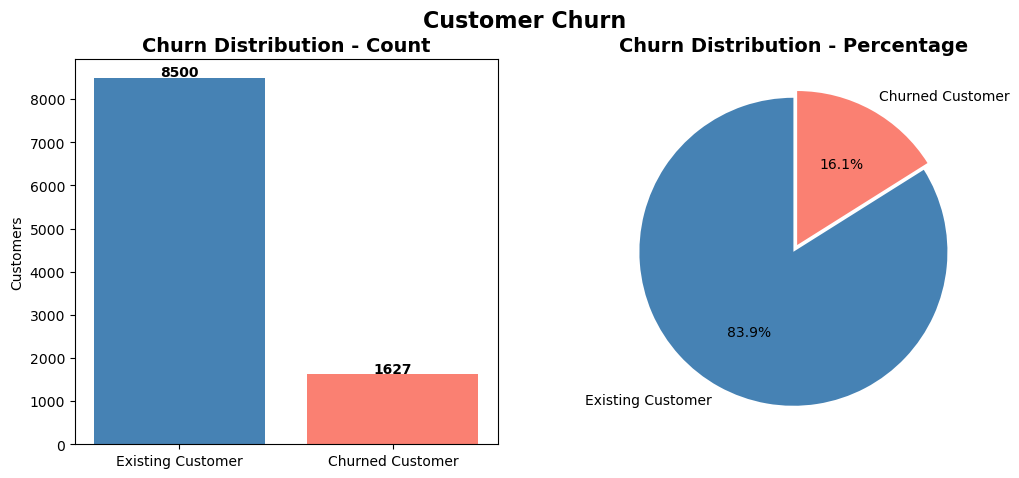

Existing Customers: 8500(83.9%)
Churned Customers:  1627(16.1%)
Class imbalance confirmed. I will use SMOTE during the modeling stage


In [3]:
fig, axes = plt.subplots(1,2,figsize=(12, 5))
churn_counts = df['Churn'].value_counts()
colors=['steelblue','salmon']
axes[0].bar(['Existing Customer','Churned Customer'],churn_counts.values,color=colors)
axes[0].set_title('Churn Distribution - Count',fontsize=14,fontweight='bold')
axes[0].set_ylabel('Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')

churn_pct = df['Churn'].value_counts()
axes[1].pie(churn_pct.values,labels=['Existing Customer', 'Churned Customer'],colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Distribution - Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Customer Churn',fontsize=16,fontweight='bold')
plt.savefig('outputs/churn_distribution.png',dpi=150, bbox_inches='tight')
plt.show()
print(f"Existing Customers: {churn_counts[0]}({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned Customers:  {churn_counts[1]}({churn_counts[1]/len(df)*100:.1f}%)")
print(f"Class imbalance confirmed. I will use SMOTE during the modeling stage")

### PART 2: Univariate Analysis

Here I examine each feature individually to understand its distribution.

#### 2.1 Categorical Features

C:\Users\Meri\AppData\Local\Temp\ipykernel_25256\837469917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c,ax=axes[i], palette='Blues_r', order=order)
C:\Users\Meri\AppData\Local\Temp\ipykernel_25256\837469917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c,ax=axes[i], palette='Blues_r', order=order)
C:\Users\Meri\AppData\Local\Temp\ipykernel_25256\837469917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=c,ax=axes[i], palette='Blues_r', order=order)
C:\Users\Meri\AppData\Local\Temp\ipyk

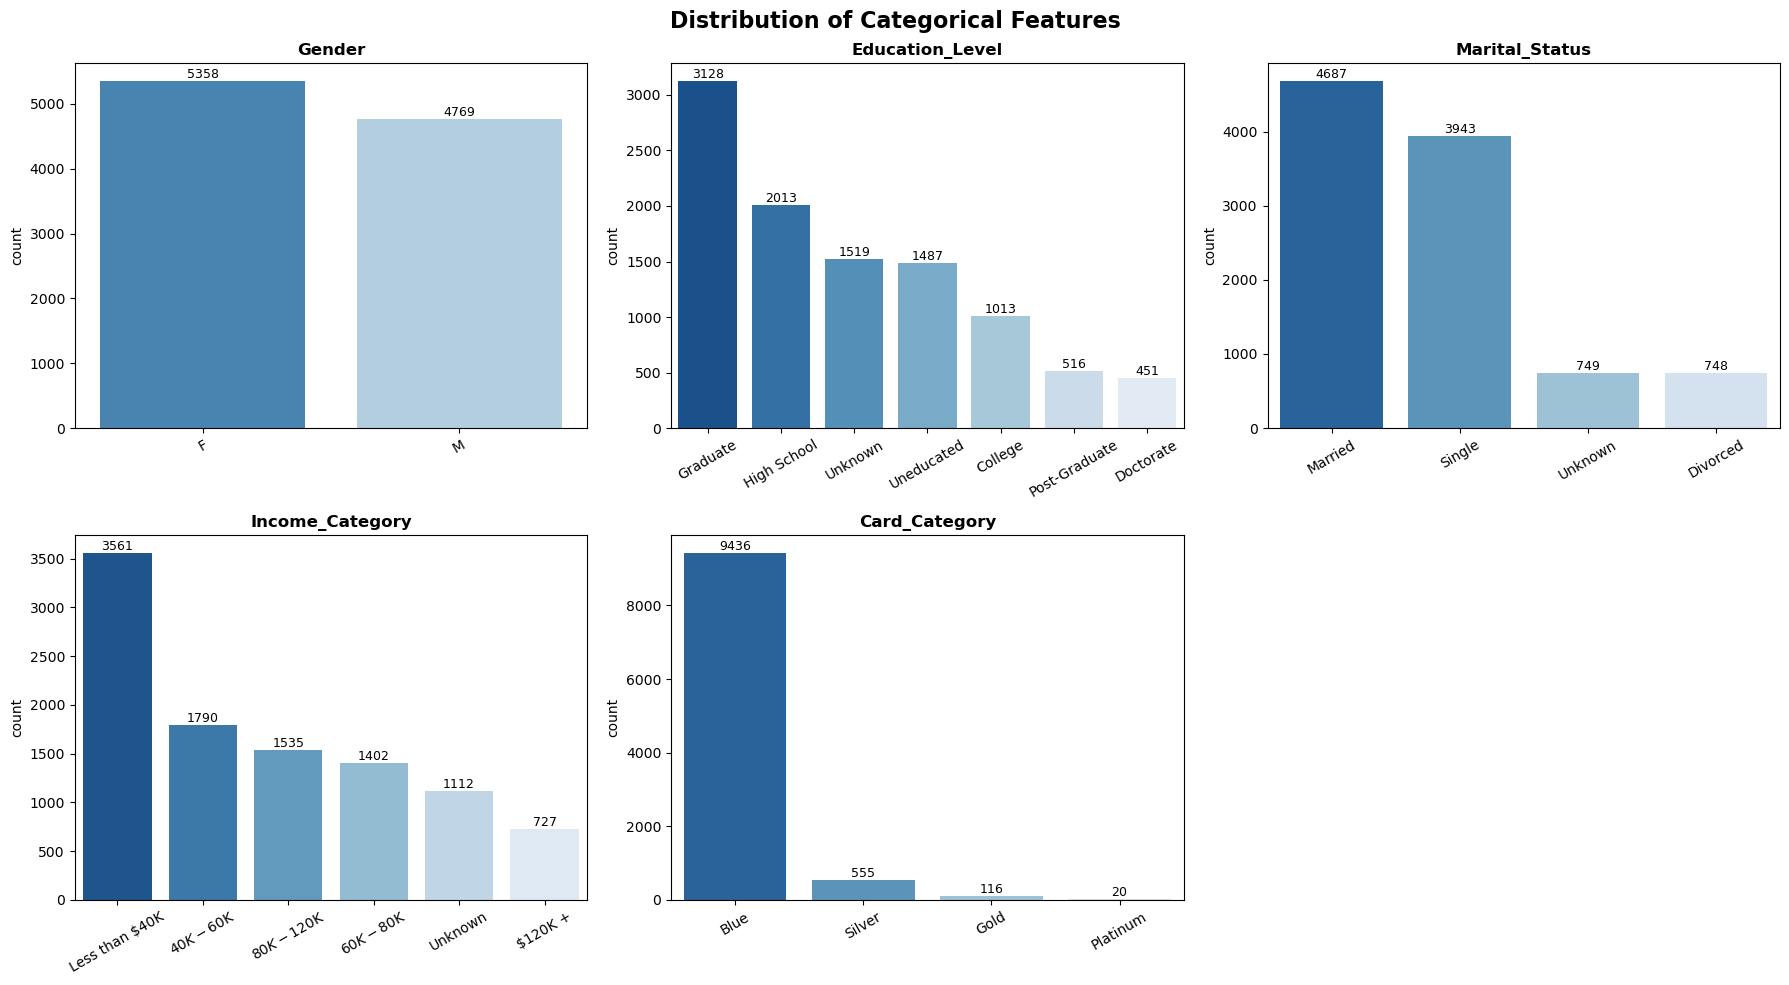

In [4]:
categorical_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
fig,axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, c in enumerate(categorical_cols):
    order = df[c].value_counts().index
    sns.countplot(data=df, x=c,ax=axes[i], palette='Blues_r', order=order)
    axes[i].set_title(f'{c}',fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x',rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Distribution of Categorical Features',fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/categorical_distributions.png',dpi=150, bbox_inches='tight')
plt.show()

#### 2.2 Numerical Features

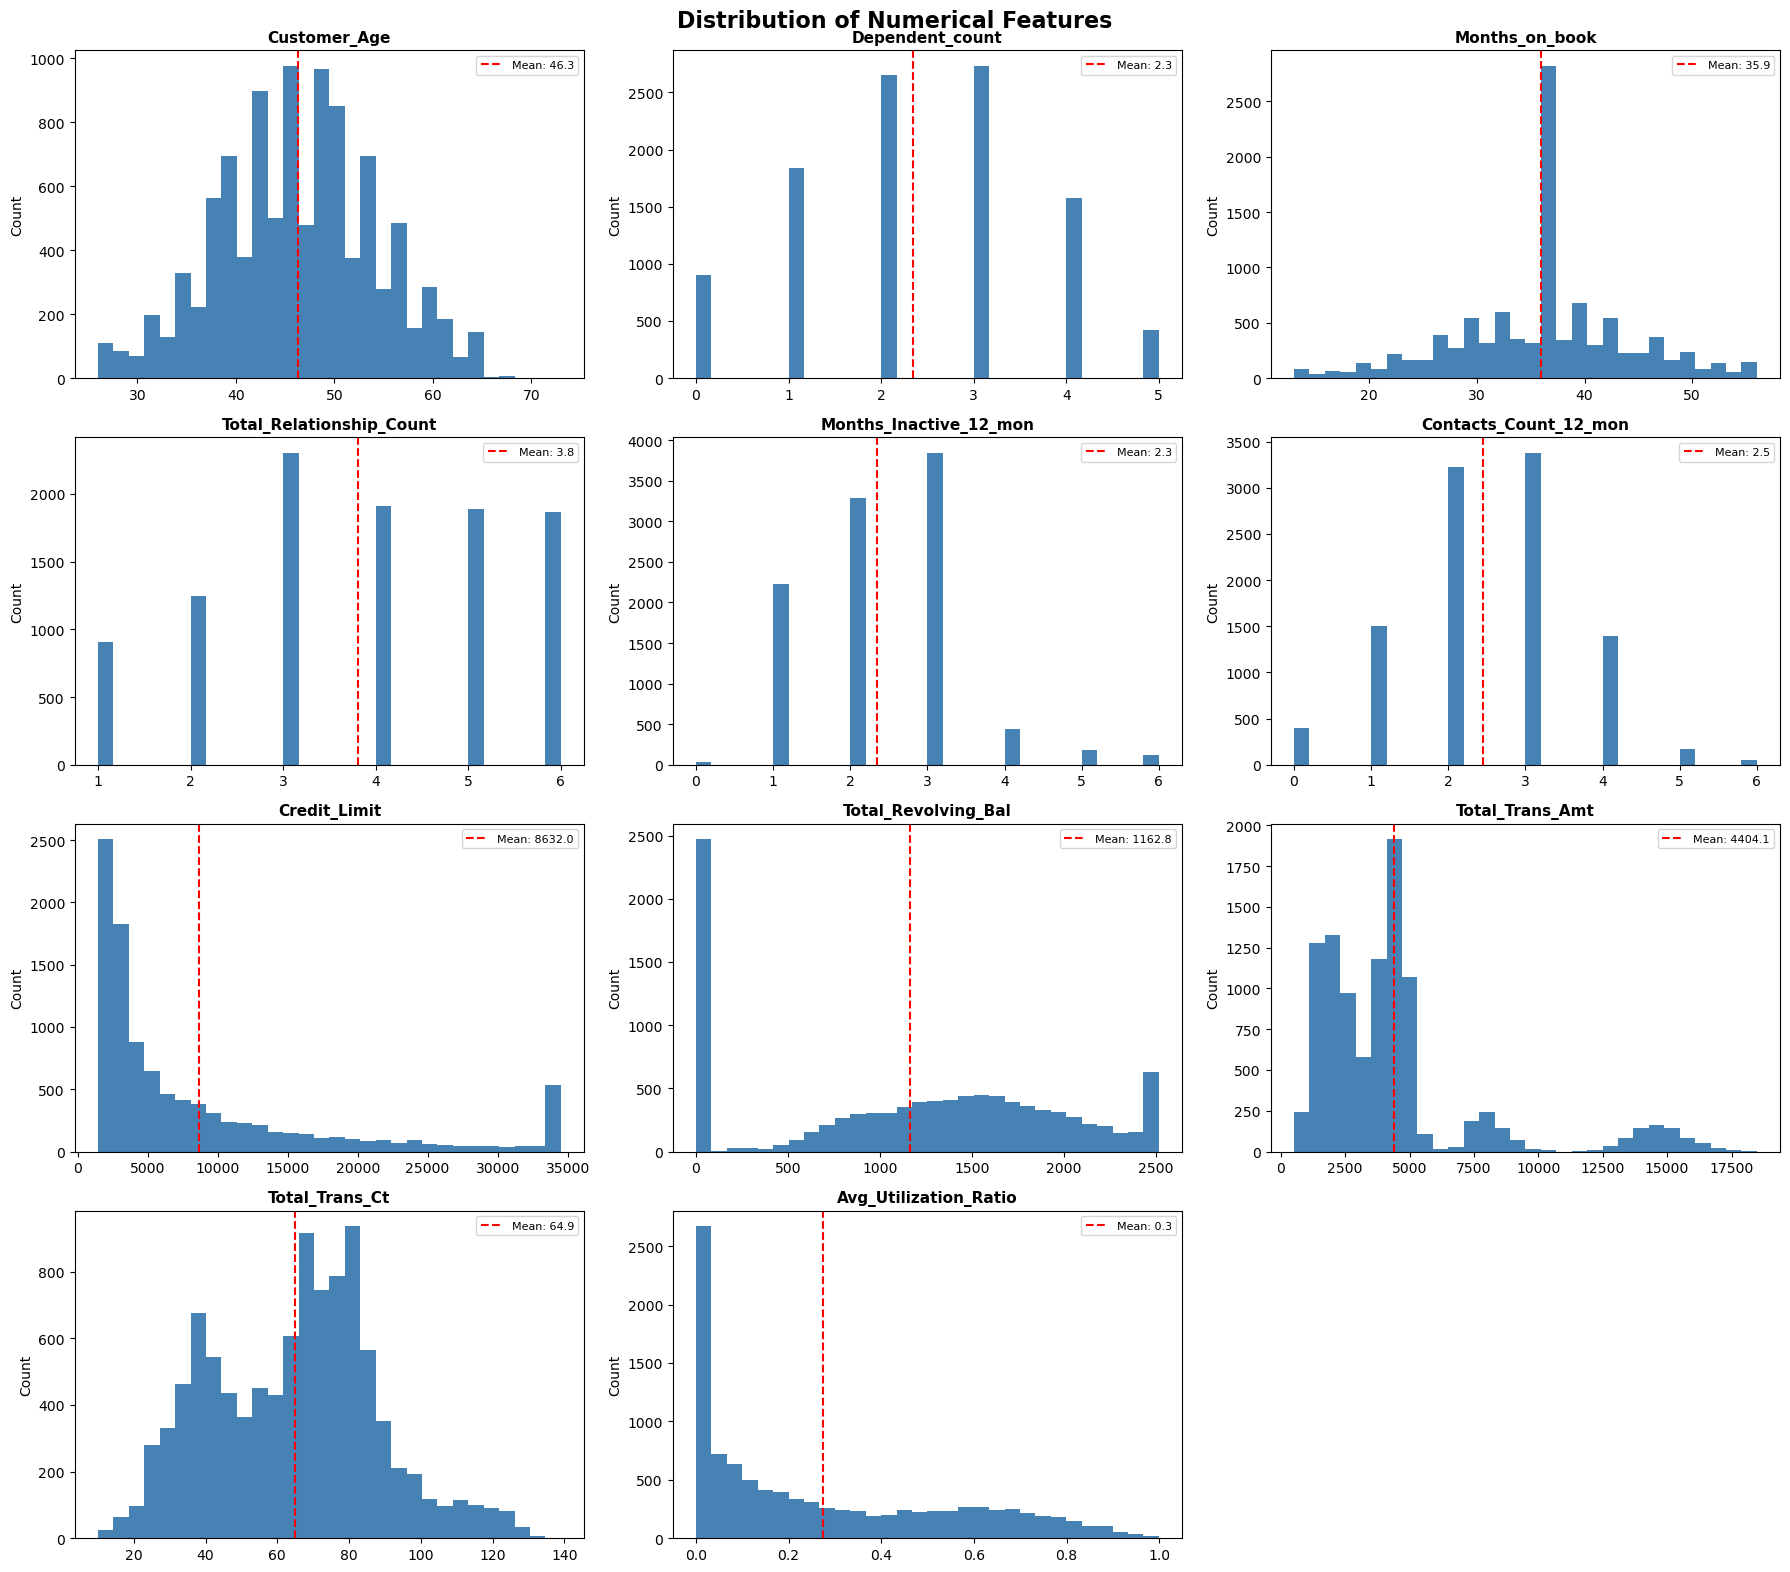

In [5]:
numerical_cols = ['Customer_Age', 'Dependent_count', 'Months_on_book','Total_Relationship_Count', 'Months_Inactive_12_mon',
                  'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Trans_Amt', 
                  'Total_Trans_Ct', 'Avg_Utilization_Ratio']
fig,axes = plt.subplots(4,3,figsize=(18,16))
axes= axes.flatten()
for i, c in enumerate(numerical_cols):
    axes[i].hist(df[c],bins=30, color='steelblue', linewidth=0.5)
    axes[i].set_title(f'{c}', fontsize=11,fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    mean=df[c].mean()
    axes[i].axvline(mean,color='red', linestyle='--',label=f'Mean: {mean:.1f}')
    axes[i].legend(fontsize = 8)
axes[11].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2.3 Outlier Check

In [6]:
Q1 = df['Credit_Limit'].quantile(0.25)
Q3 = df['Credit_Limit'].quantile(0.75)
IQR = Q3-Q1
outliers = df[(df['Credit_Limit']<Q1-1.5*IQR) | (df['Credit_Limit']>Q3+1.5*IQR)]
print(f"Outliers in Credit_Limit: {len(outliers)}")

Outliers in Credit_Limit: 984


After checking the Credit_Limit column for outliers using the IQR method, 
984 outliers were found which is around 9.7% of the data. Some customers simply have very high or very 
low credit limits and this is completely normal in real life.
Removing these records would mean losing real customer information which could 
actually make our model worse.
So I decided to keep all outliers in the dataset.

### PART 3: Bivariate Analysis

Now I compare churned vs existing customers across all features.
it reveals which features are the strongest predictors of churn.

#### 3.1 Categorical Features vs Churn

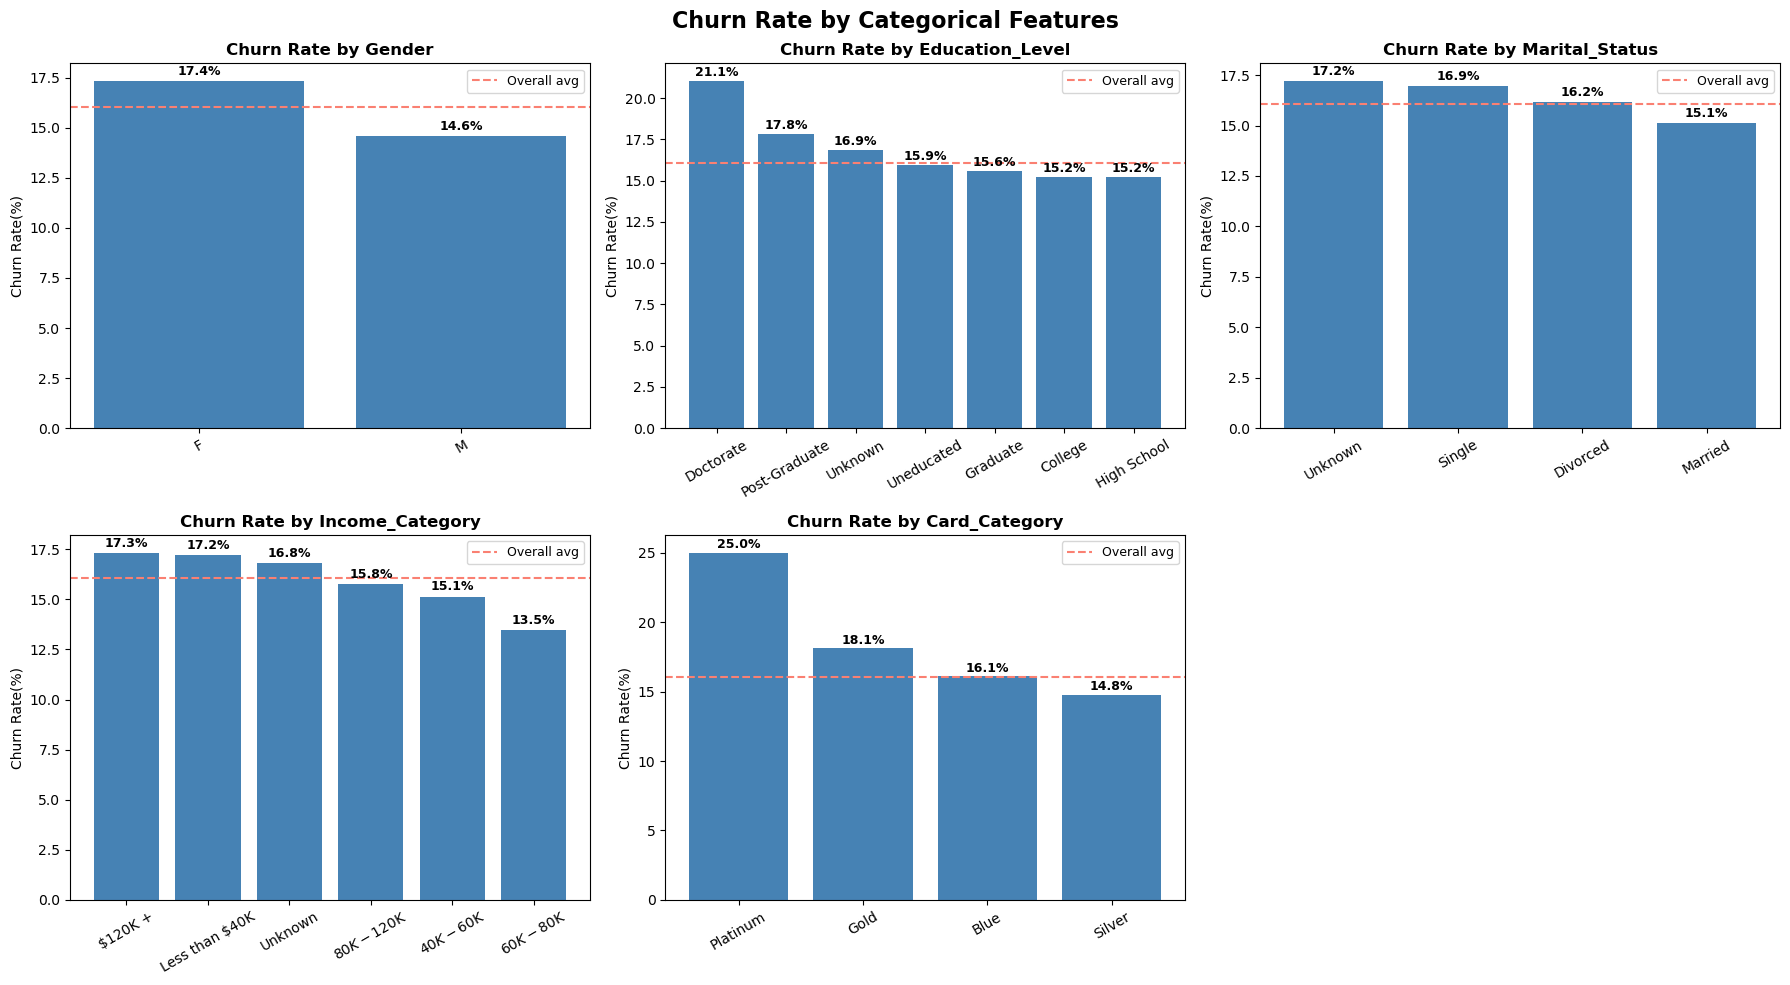

In [7]:
fig,axes =plt.subplots(2,3,figsize=(18,10))
axes = axes.flatten()

for i, c in enumerate(categorical_cols):
    churn_rate =df.groupby(c)['Churn'].mean()*100
    churn_rate =churn_rate.sort_values(ascending=False)
    bars =axes[i].bar(churn_rate.index, churn_rate.values, color='steelblue')
    axes[i].set_title(f'Churn Rate by {c}',fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate(%)')
    axes[i].tick_params(axis='x',rotation=30)
    axes[i].axhline(y=df['Churn'].mean()*100, color='salmon', linestyle='--', label='Overall avg')
    axes[i].legend(fontsize = 9)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%',ha='center', fontsize=9, fontweight='bold')
axes[5].set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.2 Numerical Features vs Churn

I focus on key numerical features and compare
their distributions between churned and existing customers.

C:\Users\Meri\AppData\Local\Temp\ipykernel_25256\1231170125.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y=c, ax=axes[i],palette=['steelblue','salmon'])
C:\Users\Meri\AppData\Local\Temp\ipykernel_25256\1231170125.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y=c, ax=axes[i],palette=['steelblue','salmon'])
C:\Users\Meri\AppData\Local\Temp\ipykernel_25256\1231170125.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y=c, ax=axes[i],palette=['st

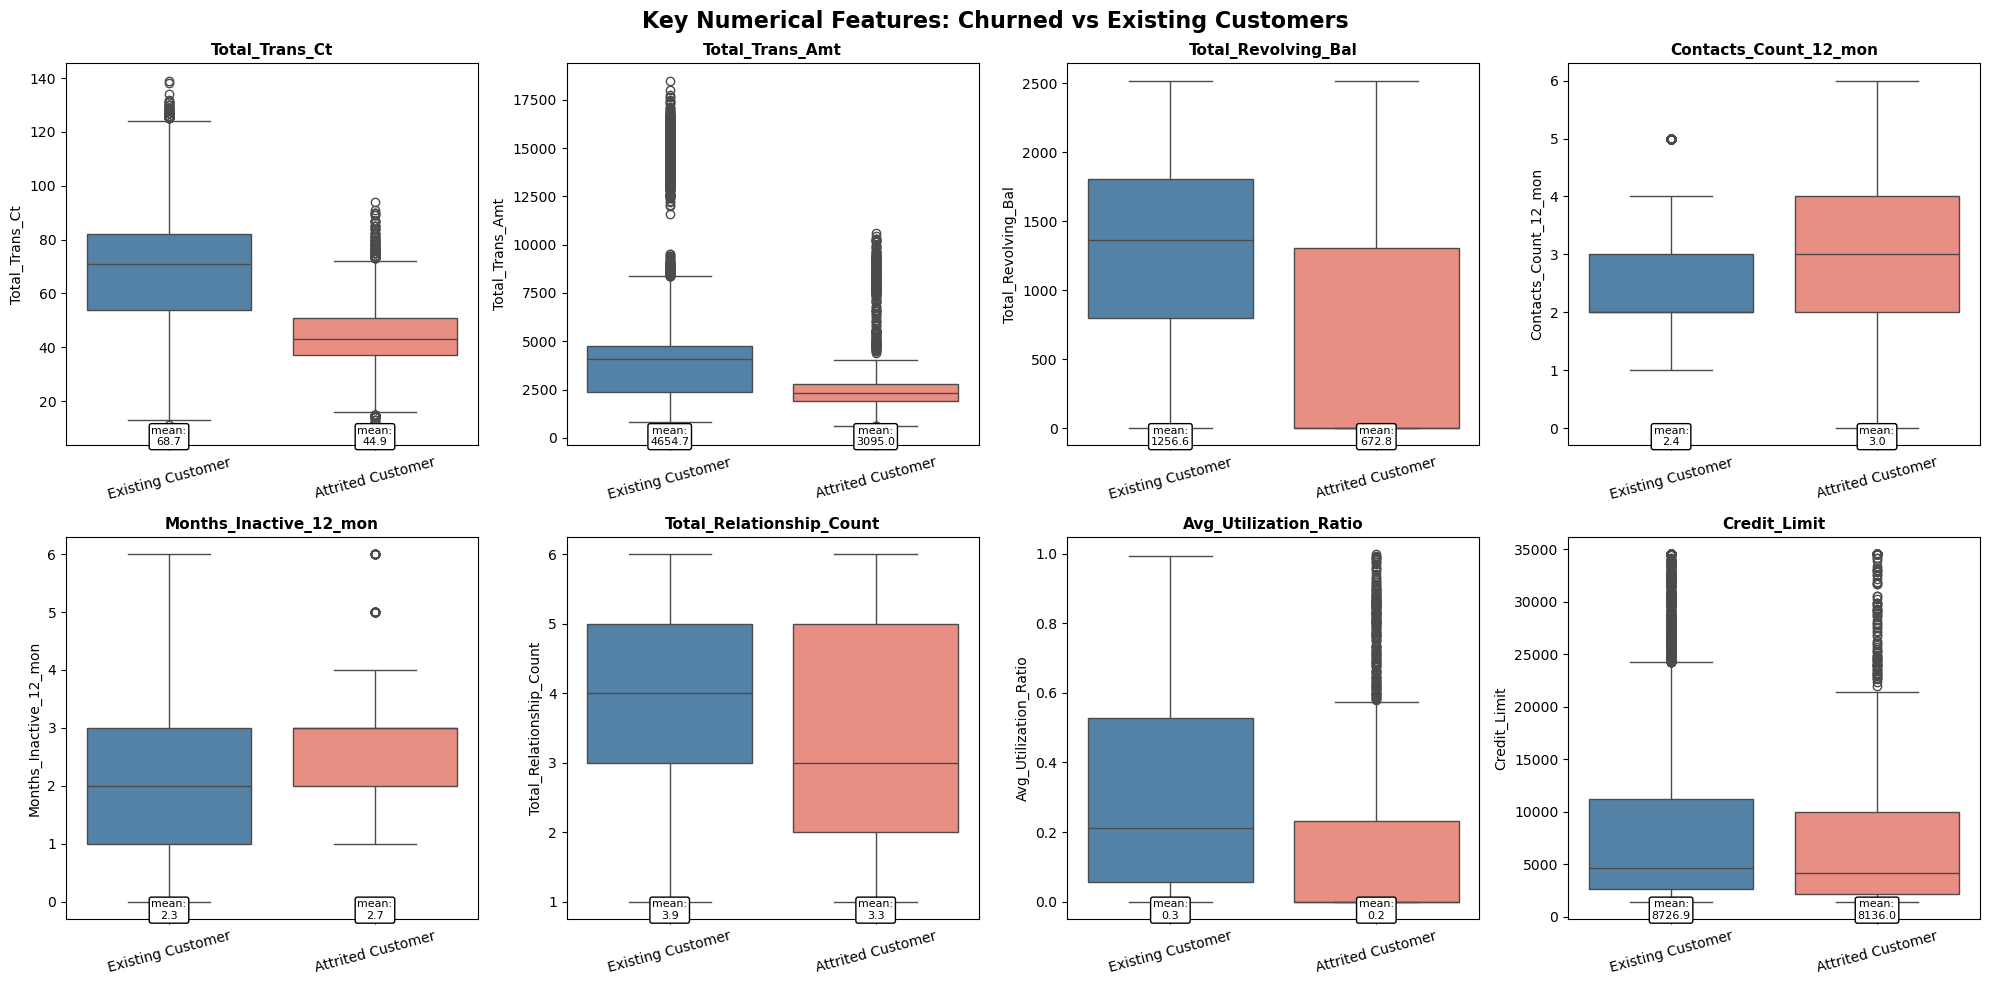

In [8]:
key_features = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal','Contacts_Count_12_mon', 
                'Months_Inactive_12_mon', 'Total_Relationship_Count', 'Avg_Utilization_Ratio', 'Credit_Limit']
fig,axes = plt.subplots(2,4,figsize=(20,10))
axes = axes.flatten()

for i, c in enumerate(key_features):
    sns.boxplot(data=df, x='Attrition_Flag', y=c, ax=axes[i],palette=['steelblue','salmon'])
    axes[i].set_title(f'{c}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x',rotation=15)
    for j, g in enumerate(['Existing Customer', 'Attrited Customer']):
        mean= df[df['Attrition_Flag']==g][c].mean()
        axes[i].text(j, axes[i].get_ylim()[0], f'mean:\n{mean:.1f}', ha='center', fontsize=8, color='black',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white'))

plt.suptitle('Key Numerical Features: Churned vs Existing Customers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/key_numerical_features_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.3 Transaction Behavior

Transaction count and amount are the strongest churn signals, so I visualize their distributions better for a clearer comparison.

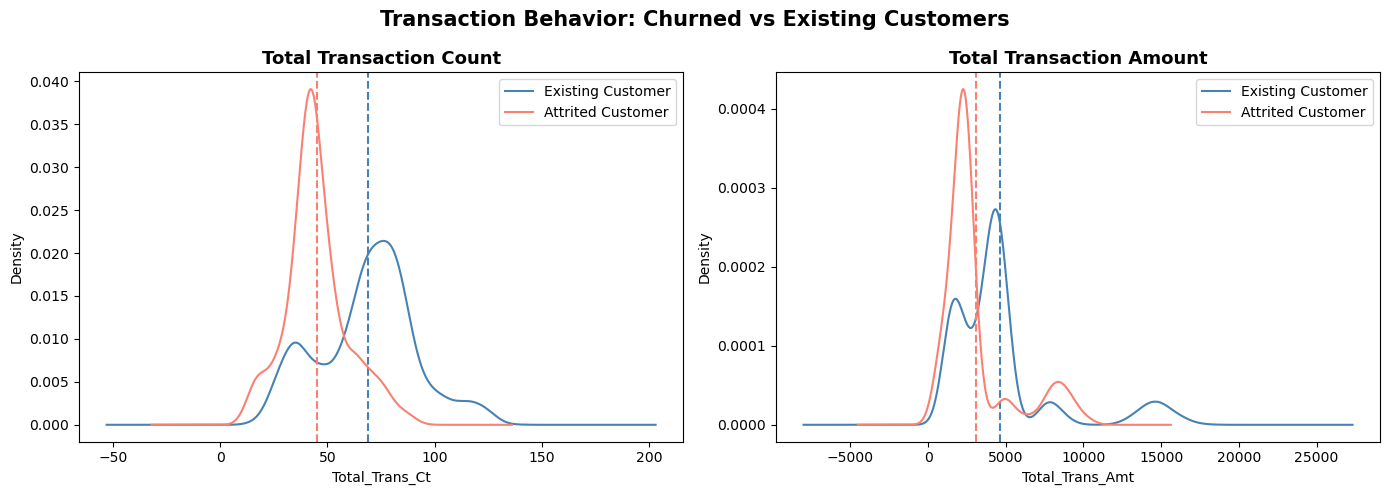

In [9]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
for ax, c, t in zip(axes, ['Total_Trans_Ct','Total_Trans_Amt'],
                           ['Total Transaction Count','Total Transaction Amount']):
    for label, color in [('Existing Customer','steelblue'),('Attrited Customer','salmon')]:
        s = df[df['Attrition_Flag'] == label][c]
        s.plot.kde(ax=ax, label=label,color=color)
        ax.axvline(s.mean(), color=color, linestyle='--')
    ax.set_title(t, fontsize=13, fontweight='bold')
    ax.set_xlabel(c)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Transaction Behavior: Churned vs Existing Customers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/transaction_kde.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.4 Age Group Analysis

I group customers into age brackets to better understand which age groups are most at risk of churning.

C:\Users\Meri\AppData\Local\Temp\ipykernel_25256\1332245162.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_age = df.groupby('Age_Group')['Churn'].mean() * 100


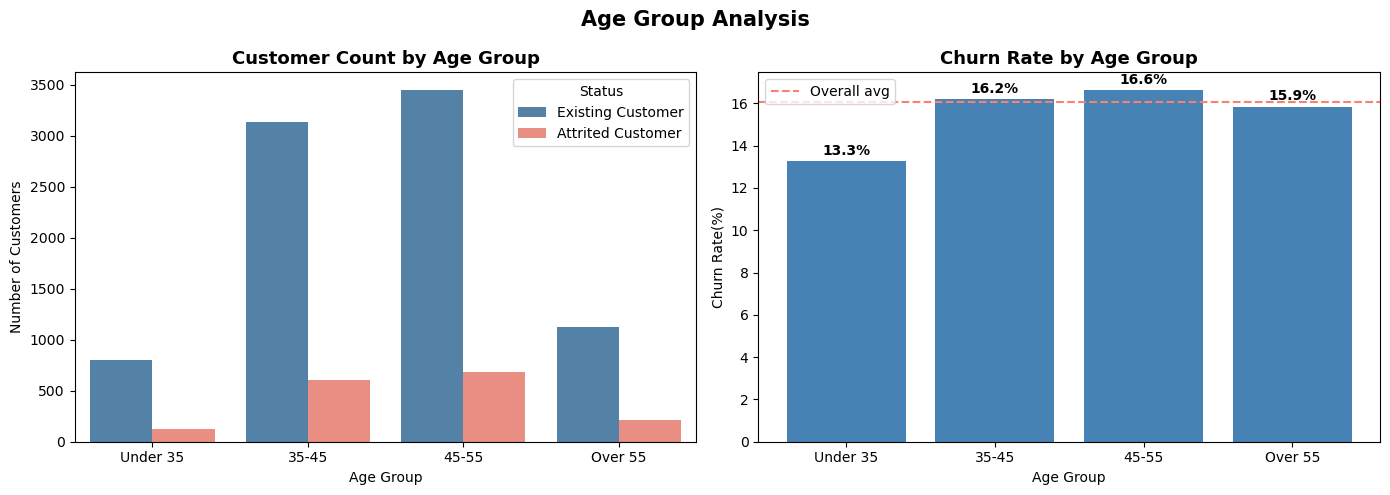

In [10]:
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=[0,35,45,55,100], labels= ['Under 35','35-45','45-55','Over 55'])
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.countplot(data=df, x='Age_Group', hue='Attrition_Flag', palette=['steelblue','salmon'], ax=axes[0])
axes[0].set_title('Customer Count by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Status')

churn_by_age = df.groupby('Age_Group')['Churn'].mean() * 100
axes[1].bar(churn_by_age.index, churn_by_age.values, color='steelblue')
axes[1].axhline(y=df['Churn'].mean()*100, color='salmon', linestyle='--', label='Overall avg')
axes[1].set_title('Churn Rate by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Churn Rate(%)')
axes[1].legend()
for i, v in enumerate(churn_by_age.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%',ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Age Group Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/age_group_analysis.png',dpi=150, bbox_inches='tight')
plt.show()

#### 3.5 Inactivity vs Contact Behavior

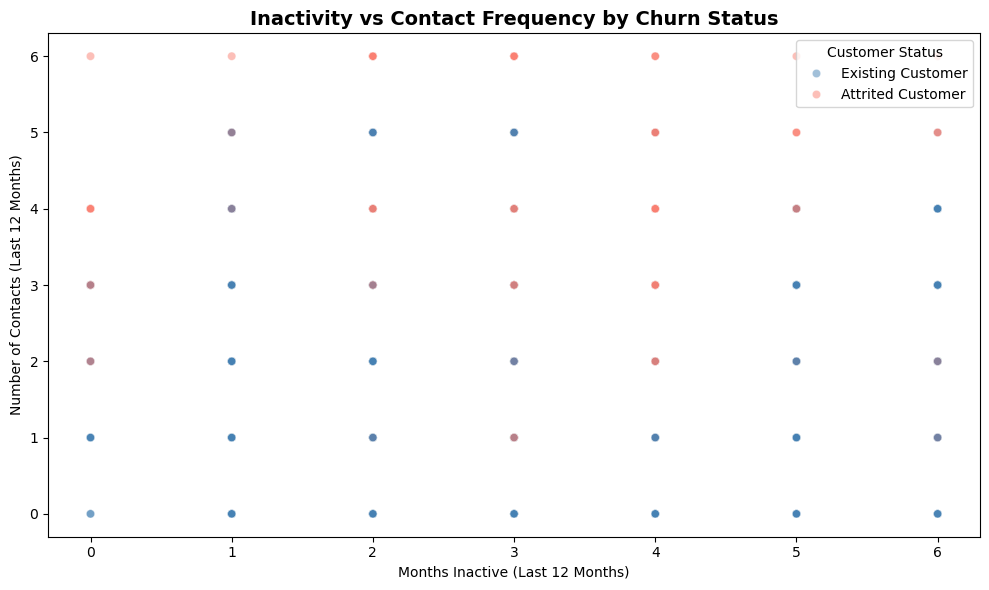

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, 
                x='Months_Inactive_12_mon', 
                y='Contacts_Count_12_mon',
                hue='Attrition_Flag',
                palette=['steelblue','salmon'],
                alpha=0.5)

plt.title('Inactivity vs Contact Frequency by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Months Inactive (Last 12 Months)')
plt.ylabel('Number of Contacts (Last 12 Months)')
plt.legend(title= 'Customer Status')
plt.tight_layout()
plt.savefig('outputs/inactivity_contacts_scatter.png',dpi=150,bbox_inches='tight')
plt.show()

### PART 4: Correlation Analysis

I examine how all numerical features relate to each other and to the target variable.

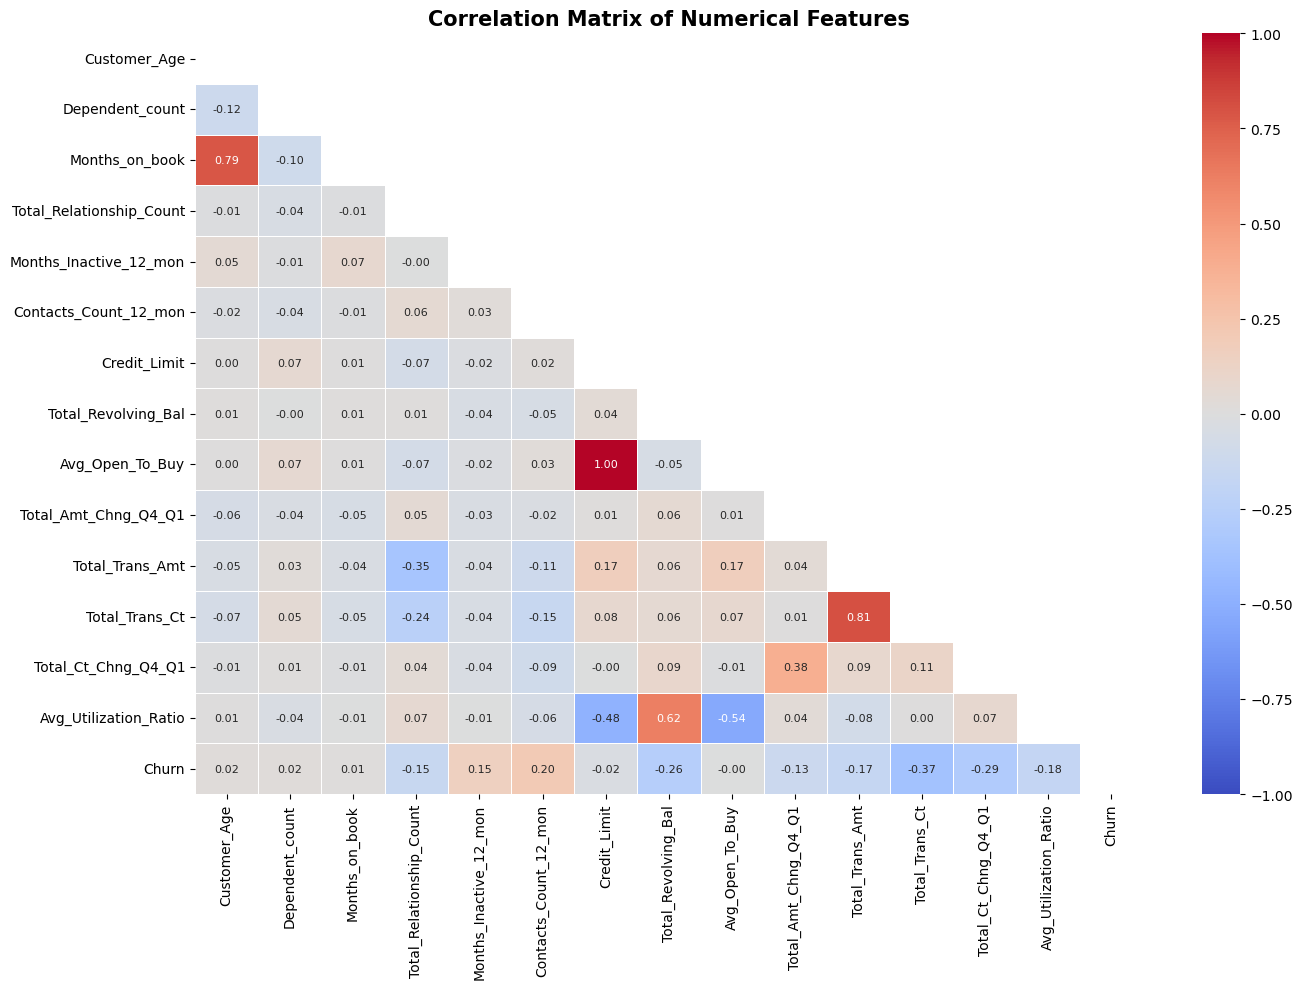

In [12]:
plt.figure(figsize=(14,10))
number_df=df.select_dtypes(include=np.number).drop('CLIENTNUM', axis=1)
corr_matrix = number_df.corr()
m=np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=m, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1,vmax=1, linewidths=0.5, annot_kws= {'size':8})
plt.title('Correlation Matrix of Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

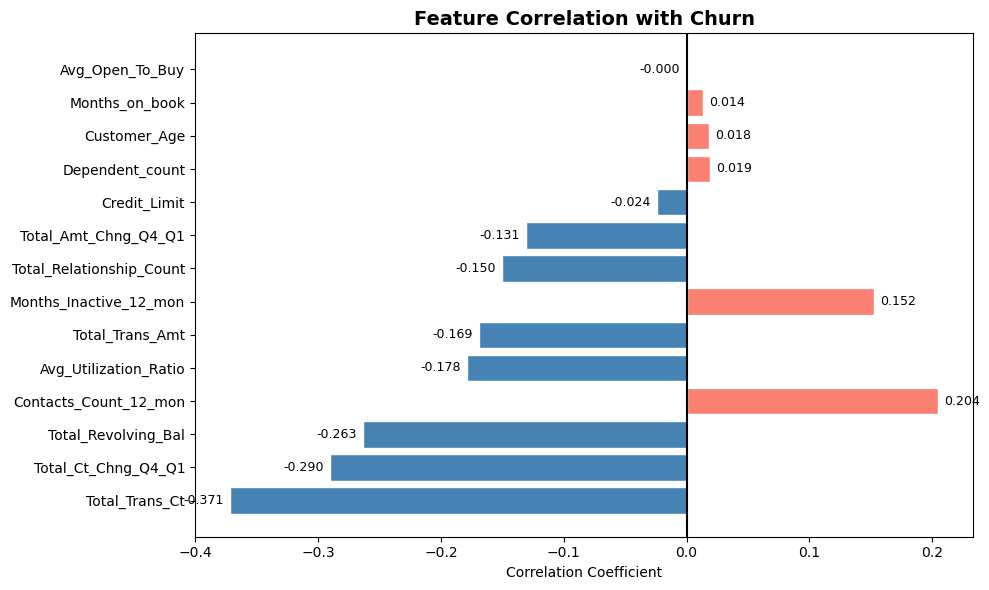


Top 5 features most correlated with Churn:
Total_Trans_Ct          -0.371403
Total_Ct_Chng_Q4_Q1     -0.290054
Total_Revolving_Bal     -0.263053
Contacts_Count_12_mon    0.204491
Avg_Utilization_Ratio   -0.178410
Name: Churn, dtype: float64


In [13]:
churn_corr = number_df.corr()['Churn'].drop('Churn').sort_values(key=abs,ascending=False)
plt.figure(figsize=(10,6))
colors = ['salmon' if x>0 else 'steelblue' for x in churn_corr.values]
bars = plt.barh(churn_corr.index,  churn_corr.values, color=colors, edgecolor='white')
plt.axvline(x=0,color= 'black')
plt.title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
for bar, val in zip(bars,churn_corr.values):
    plt.text(val+(0.005 if val>0 else -0.005), 
             bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9,
             ha='left' if val>0 else 'right')

plt.tight_layout()
plt.savefig('outputs/churn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop 5 features most correlated with Churn:")
print(churn_corr.head())

#### Top 5 Correlated Features vs Churn

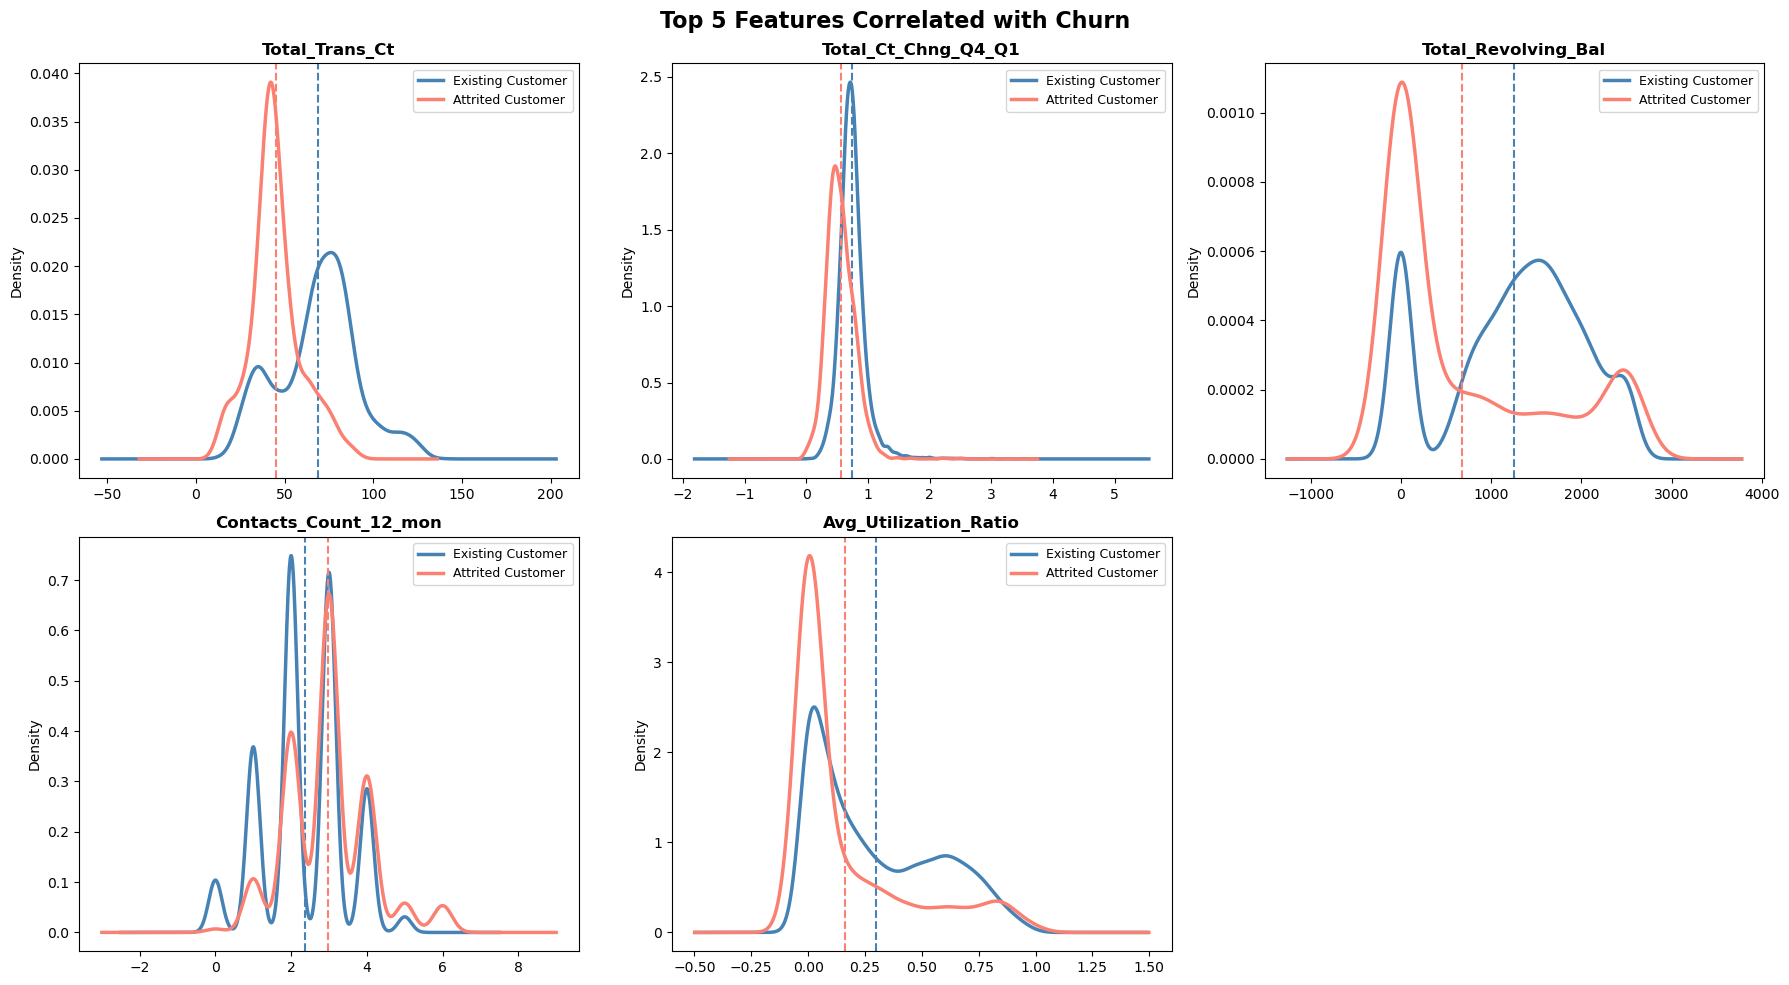

In [14]:
features = ['Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Total_Revolving_Bal', 
            'Contacts_Count_12_mon', 'Avg_Utilization_Ratio']
fig,axes = plt.subplots(2,3,figsize=(18,10))
axes = axes.flatten()
for i,col in enumerate(features):
    for lab,color in [('Existing Customer', 'steelblue'), 
                         ('Attrited Customer', 'salmon')]:
        s = df[df['Attrition_Flag'] ==lab][col]
        s.plot.kde(ax=axes[i], label=lab, color=color, linewidth=2.5)
        axes[i].axvline(s.mean(), color=color, linestyle='--', linewidth=1.5)
    axes[i].set_title(col,fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Top 5 Features Correlated with Churn', fontsize=16,fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/top5_features_kde.png', dpi=150, bbox_inches='tight')
plt.show()

### PART 5: EDA Summary & Key Findings

#### 5.1 Churn Distribution
The first thing I looked at was how many customers actually churned. The results showed that 16.1% of customers left the bank. This confirmed that there is a class imbalance in the dataset since the majority of customers are existing ones. This will need to be handled in the modeling stage using SMOTE.

#### 5.2 Customer Demographics
Looking at the demographic features I found that most of them do not have a very strong relationship with churn. Gender, for example, showed very similar churn rates for both male and female customers. Education level and marital status also did not seem to make a big difference. The income category showed that lower income customers churn slightly more. The age group analysis showed some differences between age groups but nothing important.
Overall demographic features alone are not enough to predict churn which means we need to look deeper at behavioral features.

#### 5.3 Behavioral Patterns
When I compared churned and existing customers on their actual behavior, the differences were very clear. Churned customers are making much fewer transactions and spending less money. They also show a declining trend in their transaction activity over time which means they were slowly losing interest before churning.
I also found out that churned customers contacted the bank more frequently. These customers were probably having problems or were unhappy with the service and kept calling before deciding to leave.
Churned customers also had longer periods of inactivity and lower revolving balances.

#### 5.4 Outlier Analysis
When I checked for outliers in the Credit_Limit column using the IQR method I found 984 outliers, but I decided to keep them. They are just customers with unusually high or low credit limits which is completely normal in real banking data.

#### 5.5 Correlation Analysis
The top 5 features most correlated with churn were:
1.Total_Trans_Ct;
2.Total_Ct_Chng_Q4_Q1;
3.Total_Revolving_Bal;
4.Contacts_Count_12_mon;
5.Avg_Utilization_Ratio;
I noticed that Credit_Limit and Avg_Open_To_Buy are very highly correlated with each other. This means they carry similar information so I will drop one of them before modeling.

#### 5.6 Overall Conclusion
transaction behavior is the strongest indicator of churn. Customers who are making fewer transactions, spending less, being inactive and calling the bank more are at the highest risk of leaving.
Features like Total_Trans_Ct, Total_Revolving_Bal and Contacts_Count_12_mon will be the most important inputs for the model.